# EEG Seizure Detection - Corrected Notebook

In [1]:
!pip install numpy matplotlib scikit-learn tensorflow


In [2]:
import numpy as np
import glob
import tensorflow as tf
from sklearn.model_selection import train_test_split
import os


In [3]:
# Get list of all saved batches
all_files = sorted(glob.glob("batches/batch_*.npz"))

# Split into 80% training and 20% validation
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

print("📁 Total batches:", len(all_files))
print("🟢 Train batches:", len(train_files))
print("🔵 Validation batches:", len(val_files))


📁 Total batches: 58
🟢 Train batches: 46
🔵 Validation batches: 12


In [4]:
def batch_generator(npz_files, shuffle=True):
    while True:
        if shuffle:
            np.random.shuffle(npz_files)

        for file in npz_files:
            data = np.load(file, mmap_mode='r')  # 👈 key change here

            X = data['X']  # (B, 23, 2560)
            y = data['y']  # (B,)

            # Transpose to (B, 2560, 23)
            X = np.transpose(X, (0, 2, 1))

            # Downsample from 2560 → 1280
            X = X[:, ::2, :]

            yield X, y


In [5]:
# Automatically detect number of output classes
num_classes = len(np.unique(np.load(train_files[0])['y']))

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1280, 23)),
    tf.keras.layers.Conv1D(32, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(64, 3, activation='relu'),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 1276, 32)            │           3,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 638, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 636, 64)             │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,145 (55.25 KB)

 Trainable params: 14,145 (55.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import os
import numpy as np
import glob

files = sorted(glob.glob("batches/batch_*.npz"))

for f in files:
    try:
        data = np.load(f)
        X = data["X"]
        y = data["y"]
        print(f"{f} ✅ OK → X shape: {X.shape}, y shape: {y.shape}")
        assert X.shape[1:] == (23, 2560), "Unexpected shape"
    except Exception as e:
        print(f"{f} ❌ BAD → {str(e)}")


batches\batch_0.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_1.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_10.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_11.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_12.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_13.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_14.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_15.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_16.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_17.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_18.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_19.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_2.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (1000,)
batches\batch_20.npz ✅ OK → X shape: (1000, 23, 2560), y shape: (10

In [7]:

from sklearn.utils import class_weight

# 🧮 Compute class weights
all_labels = []
for fname in os.listdir("batches"):
    path = os.path.join("batches", fname)
    data = np.load(path)
    all_labels.extend(data["y"])
    
all_labels = np.array(all_labels)
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(all_labels), y=all_labels)
class_weights = {i : weights[i] for i in range(len(weights))}

print("📊 Computed class weights:", class_weights)


📊 Computed class weights: {0: np.float64(0.501395800461221), 1: np.float64(179.6086956521739)}


In [15]:
import numpy as np
import os
from tensorflow.keras.utils import Sequence

class EEGDataGenerator(Sequence):
    def __init__(self, files, batch_size=1, downsample=4, shuffle=True):
        self.files = files
        self.batch_size = batch_size
        self.downsample = downsample
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return len(self.files) // self.batch_size

    def __getitem__(self, idx):
        batch_files = self.files[idx * self.batch_size:(idx + 1) * self.batch_size]
        X_list, y_list = [], []
        for f in batch_files:
            data = np.load(f)
            X = data['X'][:, :, ::self.downsample].astype(np.float16)
            X = np.transpose(X, (0, 2, 1))  # ⬅️ Important fix for Conv1D input
            y = data['y']
            X_list.append(X)
            y_list.append(y)
        X_batch = np.concatenate(X_list, axis=0)
        y_batch = np.concatenate(y_list, axis=0)
        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.files)


In [16]:
from sklearn.model_selection import train_test_split

all_files = sorted([os.path.join("batches", f) for f in os.listdir("batches") if f.endswith(".npz")])
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42, shuffle=True)


In [17]:
train_gen = EEGDataGenerator(train_files, batch_size=1)
val_gen = EEGDataGenerator(val_files, batch_size=1)


In [19]:
from tensorflow.keras.callbacks import EarlyStopping

# ✅ Early stopping based on validation accuracy
early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True
)

# ✅ Define model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential([
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(640, 23)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # ✅ Binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ✅ Calculate training steps
steps_per_epoch = len(train_gen)
validation_steps = len(val_gen)

# ✅ Fit the model
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=50,
    callbacks=[early_stop],
    verbose=2
)


C:\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
46/46 - 339s - 7s/step - accuracy: 0.9910 - loss: 0.1059 - val_accuracy: 0.9980 - val_loss: 0.0299
Epoch 2/50
46/46 - 336s - 7s/step - accuracy: 0.9970 - loss: 0.0262 - val_accuracy: 0.9980 - val_loss: 0.0193
Epoch 3/50
46/46 - 314s - 7s/step - accuracy: 0.9970 - loss: 0.0241 - val_accuracy: 0.9980 - val_loss: 0.0152
Epoch 4/50
46/46 - 320s - 7s/step - accuracy: 0.9970 - loss: 0.0240 - val_accuracy: 0.9980 - val_loss: 0.0174
Epoch 5/50
46/46 - 491s - 11s/step - accuracy: 0.9970 - loss: 0.0228 - val_accuracy: 0.9980 - val_loss: 0.0145
Epoch 6/50
46/46 - 313s - 7s/step - accuracy: 0.9970 - loss: 0.0228 - val_accuracy: 0.9980 - val_loss: 0.0159


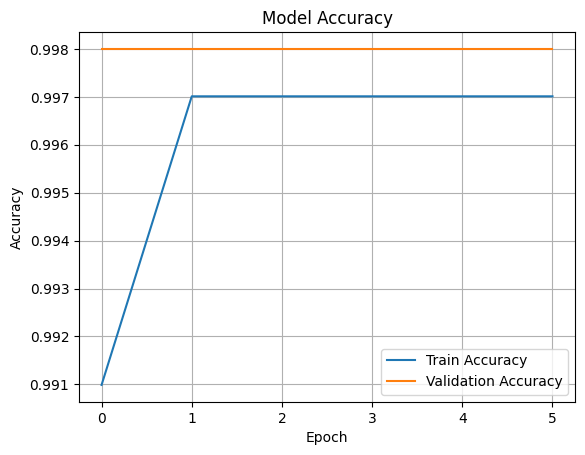

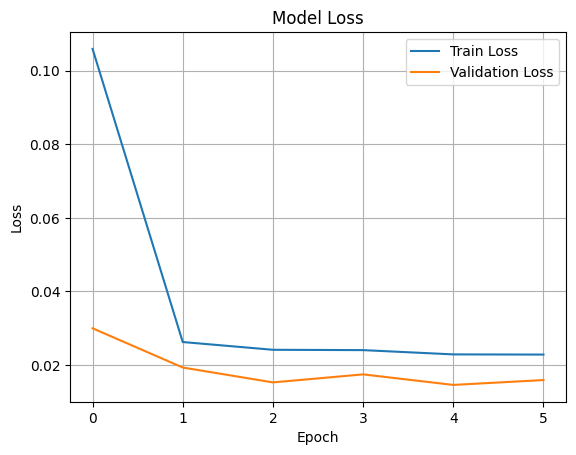

In [21]:
import matplotlib.pyplot as plt

# 📊 Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 📉 Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [23]:
# Save your model in TensorFlow's SavedModel format (recommended)
model.save("EEG_Seizure_Detector_CNN.keras")
print("✅ Model saved successfully in 'EEG_Seizure_Detector_CNN/' folder.")


✅ Model saved successfully in 'EEG_Seizure_Detector_CNN/' folder.
